In [1]:
import numpy as np
import pandas as pd


In [13]:
literacy_df=pd.read_csv('literacy_rate.csv')

In [14]:
literacy_df.head()

,Sl. No.,State/UT,2019-20,2020-21,2021-22,2022-23,2023-24
0,1,Andhra Pradesh,63.2,64.4,68.5,67.6,67.5
1,2,Arunachal Pradesh,81.9,83.6,78.4,82.8,82.9
2,3,Assam,87.0,88.5,87.2,76.8,86.2
3,4,Bihar,71.0,73.2,73.3,73.7,73.3
4,5,Chhattisgarh,76.1,75.3,77.0,76.2,76.6


In [6]:
spending_df=pd.read_csv('india_spending.csv')

In [8]:
spending_df.head()

,Country,Code,Year,Total across all levels of education
0,India,IND,1997,3.36136
1,India,IND,1998,3.57256
2,India,IND,1999,4.41539
3,India,IND,2000,4.32479
4,India,IND,2003,3.61341


In [9]:
pop_df=pd.read_csv('population.csv')

In [11]:
pop_df.head()

,Rank,State/Union Territory,1951,1961,1971,1981,1991,2001,2011
0,1,Uttar Pradesh,"60,274,800","70,144,160","83,849,775","105,113,300","132,062,800","166,053,600","199,581,477"
1,2,Maharashtra,"32,002,500","39,554,900","50,412,240","62,782,820","78,937,190","96,752,500","112,372,972"
2,3,Bihar,"29,085,900","34,841,490","42,126,800","52,303,000","64,531,200","82,879,910","103,804,630"
3,4,West Bengal,"26,300,670","34,926,000","44,312,017","54,580,650","68,077,970","80,221,300","91,347,736"
4,5,Madhya Pradesh,"18,615,700","23,218,950","30,017,180","38,169,500","48,566,800","60,385,090","72,597,565"


In [15]:
literacy_df.info()
spending_df.info()
pop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Sl. No.   38 non-null     object 
 1   State/UT  38 non-null     object 
 2   2019-20   38 non-null     float64
 3   2020-21   37 non-null     float64
 4   2021-22   37 non-null     float64
 5   2022-23   37 non-null     float64
 6   2023-24   36 non-null     float64
dtypes: float64(5), object(2)
memory usage: 2.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 4 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Country                               22 non-null     object 
 1   Code                                  22 non-null     object 
 2   Year                                  22 non-null     int64  
 3   Total across all levels of education  22 non-null    

In [ ]:
#cleaning

In [16]:
literacy_df = literacy_df.drop(columns=["Sl. No."])

literacy_long = literacy_df.melt(
    id_vars="State/UT",
    var_name="Year",
    value_name="Literacy_Rate"
)

literacy_long.head()

,State/UT,Year,Literacy_Rate
0,Andhra Pradesh,2019-20,63.2
1,Arunachal Pradesh,2019-20,81.9
2,Assam,2019-20,87.0
3,Bihar,2019-20,71.0
4,Chhattisgarh,2019-20,76.1


In [21]:

spending = spending_df[["Year", "Total across all levels of education"]].copy()

spending.rename(columns={
    "Total across all levels of education": "Spending"
}, inplace=True)

spending.head()

,Year,Spending
0,1997,3.36136
1,1998,3.57256
2,1999,4.41539
3,2000,4.32479
4,2003,3.61341


In [18]:
spending = spending[spending["Year"] >= 2010]


In [23]:
population = pop_df[["State/Union Territory", "2011"]].copy()

population.rename(columns={
    "State/Union Territory": "State",
    "2011": "Population"
}, inplace=True)

population.head()

,State,Population
0,Uttar Pradesh,"199,581,477"
1,Maharashtra,"112,372,972"
2,Bihar,"103,804,630"
3,West Bengal,"91,347,736"
4,Madhya Pradesh,"72,597,565"


In [24]:
literacy_long.rename(columns={"State/UT": "State"}, inplace=True)

literacy_long["State"] = literacy_long["State"].str.strip()
population["State"] = population["State"].str.strip()

In [30]:
#merging dataframe(literacy and population on basis of state)
df = pd.merge(literacy_long, population, on="State")

,State,Year,Literacy_Rate,Population
0,Andhra Pradesh,2019-20,63.2,"49,386,799"
1,Arunachal Pradesh,2019-20,81.9,"1,382,611"
2,Assam,2019-20,87.0,"31,169,272"
3,Bihar,2019-20,71.0,"103,804,630"
4,Chhattisgarh,2019-20,76.1,"25,540,196"
...,...,...,...,...
170,Dadra and Nagar Haveli,2023-24,75.8,"342,853"
171,Daman and Diu,2023-24,NaN,"242,911"
172,Jammu and Kashmir,2023-24,81.4,"12,548,926"
173,Lakshadweep,2023-24,99.5,"64,429"


In [33]:
#merging the already merged dataset with spending
print("DF Years:", df["Year"].unique())
print("Spending Years:", spending["Year"].unique())

DF Years: [2019 2020 2021 2022]
Spending Years: [1997 1998 1999 2000 2003 2004 2005 2006 2009 2010 2011 2012 2013 2014
 2015 2016 2017 2018 2019 2020 2021 2022]


In [42]:
df["Year"] = df["Year"].astype(str).str[:4].astype(int)
spending["Year"] = spending["Year"].astype(int)

In [43]:
df_final = pd.merge(df, spending, on="Year")

In [44]:
df_final

,State,Year,Literacy_Rate,Population,Spending
0,Andhra Pradesh,2019,63.2,"49,386,799",3.897324
1,Arunachal Pradesh,2019,81.9,"1,382,611",3.897324
2,Assam,2019,87.0,"31,169,272",3.897324
3,Bihar,2019,71.0,"103,804,630",3.897324
4,Chhattisgarh,2019,76.1,"25,540,196",3.897324
...,...,...,...,...,...
135,Dadra and Nagar Haveli,2022,81.3,"342,853",4.098658
136,Daman and Diu,2022,NaN,"242,911",4.098658
137,Jammu and Kashmir,2022,77.0,"12,548,926",4.098658
138,Lakshadweep,2022,100.0,"64,429",4.098658


In [45]:
print(df.columns)

Index(['State', 'Year', 'Literacy_Rate', 'Population'], dtype='object')


In [46]:
df = df.drop(columns=[col for col in df.columns if "Spending" in col], errors='ignore')

In [47]:
df_final = pd.merge(df, spending, on="Year")

In [49]:
df_final

,State,Year,Literacy_Rate,Population,Spending
0,Andhra Pradesh,2019,63.2,"49,386,799",3.897324
1,Arunachal Pradesh,2019,81.9,"1,382,611",3.897324
2,Assam,2019,87.0,"31,169,272",3.897324
3,Bihar,2019,71.0,"103,804,630",3.897324
4,Chhattisgarh,2019,76.1,"25,540,196",3.897324
...,...,...,...,...,...
135,Dadra and Nagar Haveli,2022,81.3,"342,853",4.098658
136,Daman and Diu,2022,NaN,"242,911",4.098658
137,Jammu and Kashmir,2022,77.0,"12,548,926",4.098658
138,Lakshadweep,2022,100.0,"64,429",4.098658


In [50]:
df_final.info()
df_final.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   State          140 non-null    object 
 1   Year           140 non-null    int64  
 2   Literacy_Rate  137 non-null    float64
 3   Population     140 non-null    object 
 4   Spending       140 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 5.6+ KB


,Year,Literacy_Rate,Spending
count,140.000000,137.000000,140.000000
mean,2020.500000,81.860584,4.166406
std,1.122048,8.995255,0.278211
min,2019.000000,62.300000,3.897324
25%,2019.750000,75.500000,4.004437
50%,2020.500000,80.800000,4.069400
75%,2021.250000,88.800000,4.231368
max,2022.000000,100.000000,4.629499


In [51]:
df_final['Literacy_Rate'].isnull().sum()

np.int64(3)

In [52]:
df_final.isnull().sum()

State            0
Year             0
Literacy_Rate    3
Population       0
Spending         0
dtype: int64

In [53]:
df_final = df_final.dropna()

In [54]:
df_final.isnull().sum()

State            0
Year             0
Literacy_Rate    0
Population       0
Spending         0
dtype: int64

In [55]:
df_final.corr(numeric_only=True)

,Year,Literacy_Rate,Spending
Year,1.000000,0.099397,0.485938
Literacy_Rate,0.099397,1.000000,0.048096
Spending,0.485938,0.048096,1.000000


In [ ]:
#visualisation

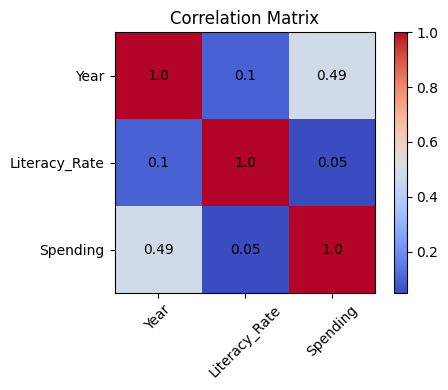

In [64]:
import matplotlib.pyplot as plt


# correlation
corr = df_final.corr(numeric_only=True)
# plot
plt.figure(figsize=(5,4))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()

# labels
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

# values inside boxes
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, round(corr.iloc[i, j], 2),
                 ha='center', va='center')

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
#Literacy trend overtime

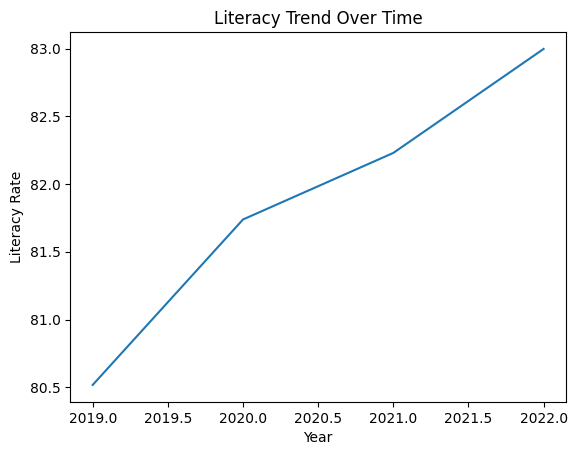

In [65]:
avg_lit = df_final.groupby("Year")["Literacy_Rate"].mean()

plt.plot(avg_lit.index, avg_lit.values)
plt.title("Literacy Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Literacy Rate")
plt.show()

In [ ]:
#Literacy Trend

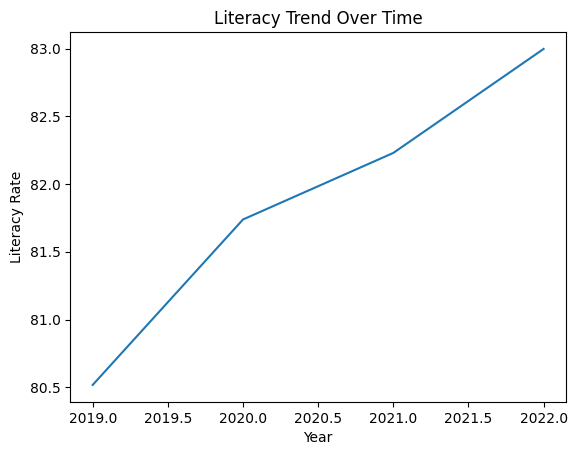

In [68]:
plt.plot(df_final.groupby("Year")["Literacy_Rate"].mean())
plt.title("Literacy Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Literacy Rate")
plt.show()


In [ ]:
#Spending trend over Time

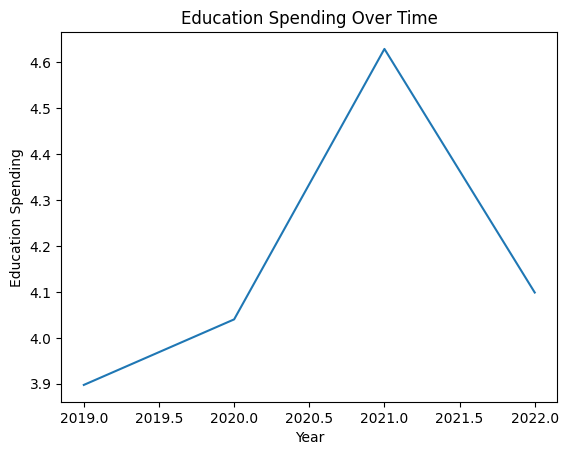

In [71]:
sp_trend = df_final.groupby("Year")["Spending"].mean()
plt.plot(sp_trend.index, sp_trend.values)
plt.xlabel("Year")
plt.ylabel("Education Spending")
plt.title("Education Spending Over Time")

plt.show()

In [ ]:
#Spending vs Literacy 

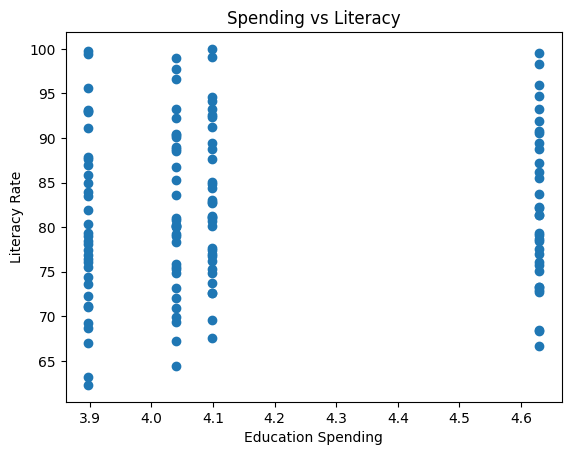

In [72]:
plt.scatter(df_final["Spending"], df_final["Literacy_Rate"])

plt.xlabel("Education Spending")
plt.ylabel("Literacy Rate")
plt.title("Spending vs Literacy")
plt.show()

In [ ]:
#Population vs Literacy

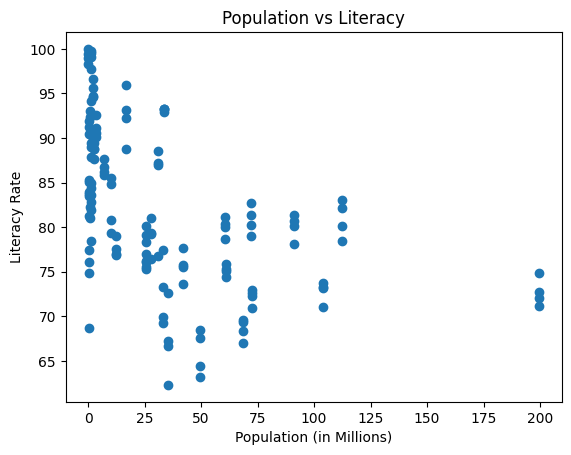

In [81]:
df_final = df_final.copy()

df_final["Population_M"] = df_final["Population"] / 1_000_000
plt.scatter(df_final["Population_M"], df_final["Literacy_Rate"])
plt.xlabel("Population (in Millions)")
plt.ylabel("Literacy Rate")
plt.title("Population vs Literacy")

plt.show()

In [ ]:
#latest year literacy rate based upon each state

In [82]:
latest = df_final[df_final["Year"] == df_final["Year"].max()]

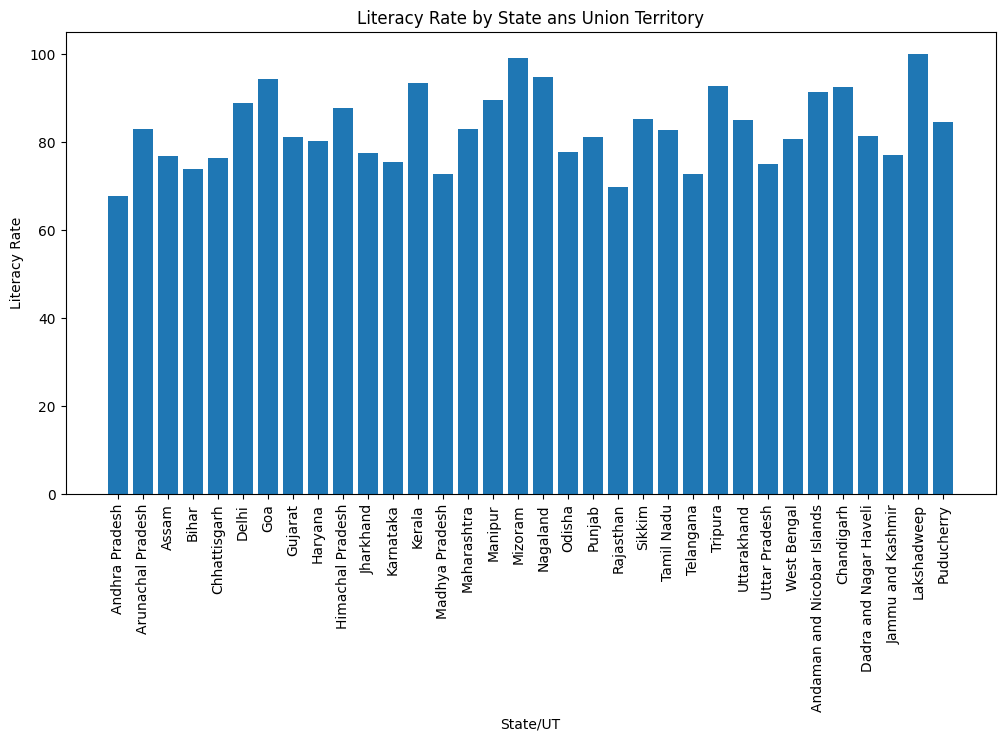

In [85]:
plt.figure(figsize=(12,6))
plt.bar(latest["State"], latest["Literacy_Rate"])
plt.xticks(rotation=90)
plt.xlabel("State/UT")
plt.ylabel("Literacy Rate")
plt.title("Literacy Rate by State ans Union Territory")

plt.show()

In [ ]:
# population vs literacy rate (state-wise)

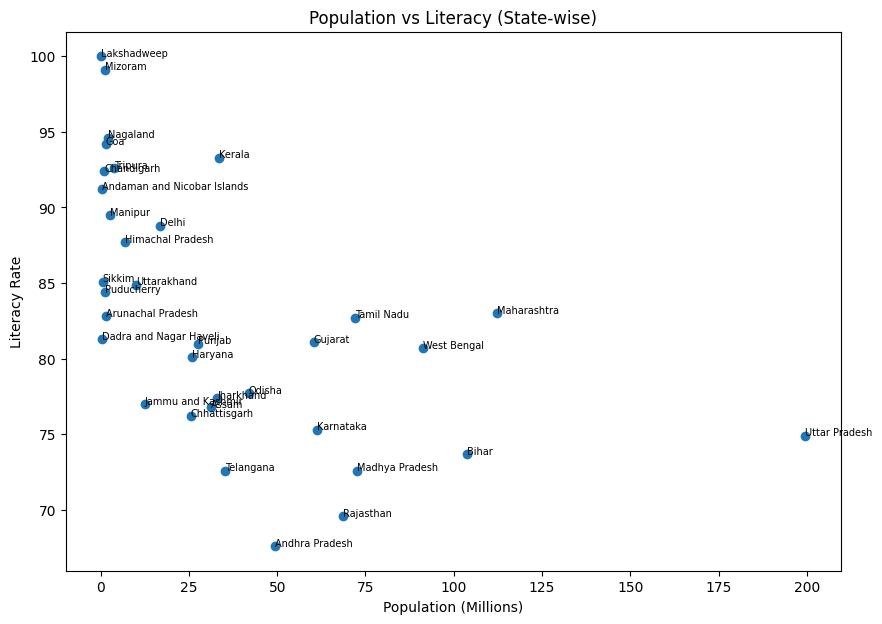

In [86]:
plt.figure(figsize=(10,7))
plt.scatter(latest["Population_M"], latest["Literacy_Rate"])
for i in range(len(latest)):
    plt.text(latest["Population_M"].iloc[i],
             latest["Literacy_Rate"].iloc[i],
             latest["State"].iloc[i],
             fontsize=7)

plt.xlabel("Population (Millions)")
plt.ylabel("Literacy Rate")
plt.title("Population vs Literacy (State-wise)")

plt.show()

In [ ]:
#Multi_Year Scatter

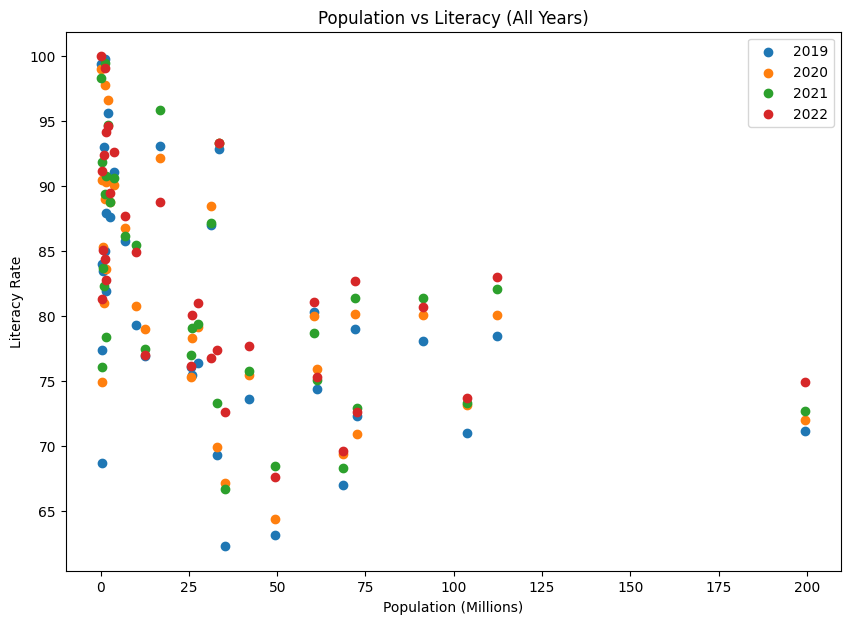

In [87]:
plt.figure(figsize=(10,7))
years = df_final["Year"].unique()
for year in years:
    data = df_final[df_final["Year"] == year]
    plt.scatter(data["Population_M"], data["Literacy_Rate"], label=year)

plt.xlabel("Population (Millions)")
plt.ylabel("Literacy Rate")
plt.title("Population vs Literacy (All Years)")

plt.legend()
plt.show()

In [ ]:
#Literacy rate per state

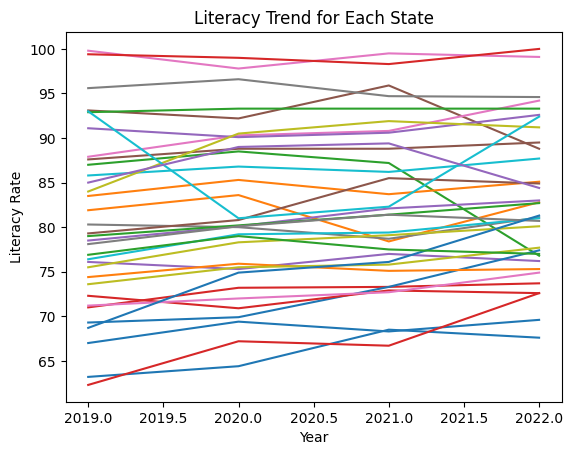

In [88]:
for state in df_final["State"].unique():
    data = df_final[df_final["State"] == state]
    plt.plot(data["Year"], data["Literacy_Rate"])

plt.xlabel("Year")
plt.ylabel("Literacy Rate")
plt.title("Literacy Trend for Each State")

plt.show()

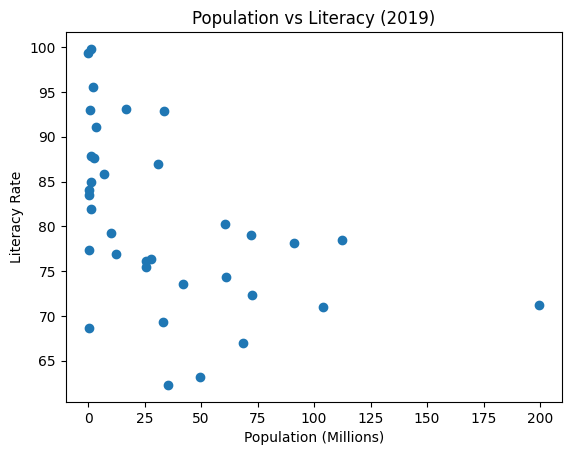

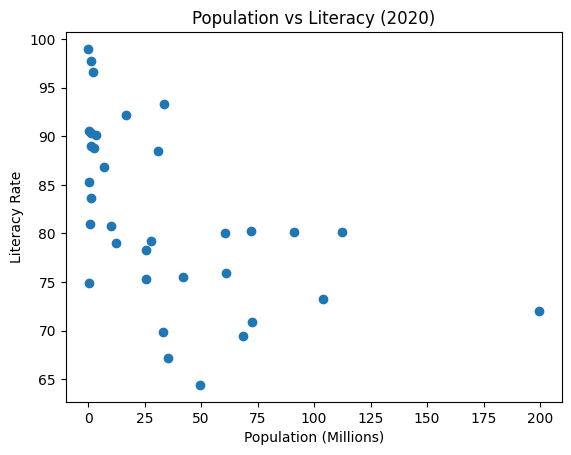

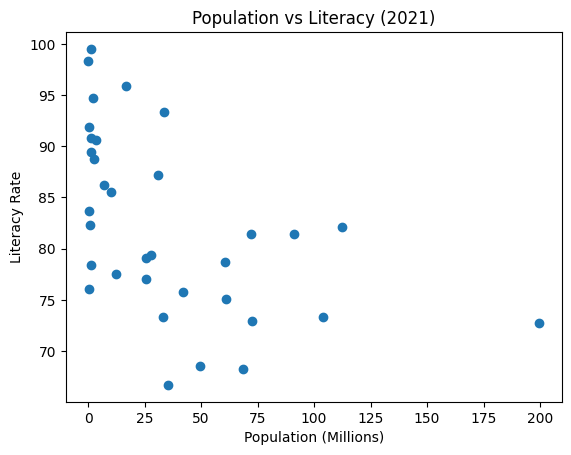

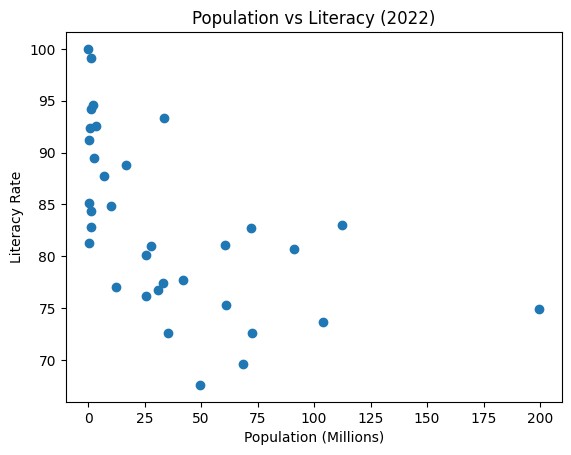

In [89]:
years = sorted(df_final["Year"].unique())
for year in years:
    data = df_final[df_final["Year"] == year]
    plt.figure()
    plt.scatter(data["Population_M"], data["Literacy_Rate"])
    
    plt.xlabel("Population (Millions)")
    plt.ylabel("Literacy Rate")
    plt.title(f"Population vs Literacy ({year})")
    
    plt.show()

In [ ]:
#spending per state

In [ ]:
#top vs botto states(High scoring graph)

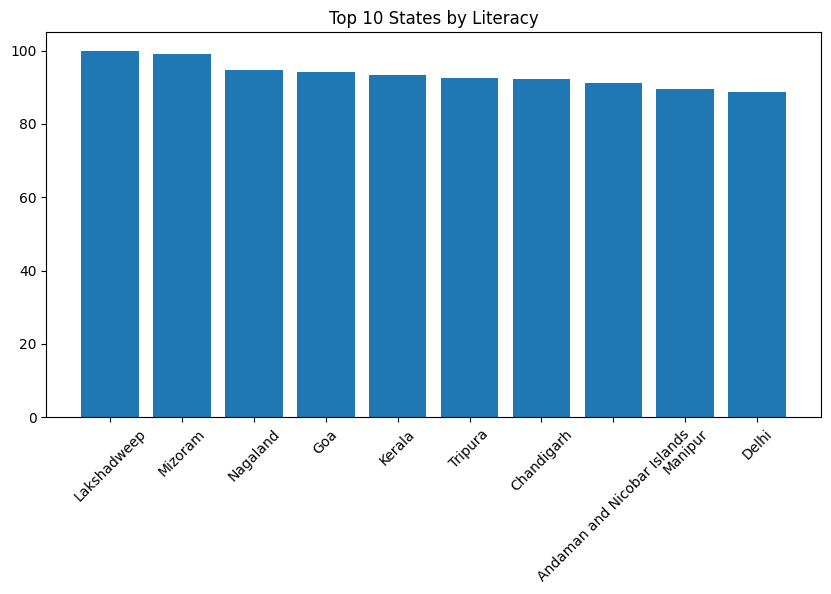

In [90]:
latest = df_final[df_final["Year"] == df_final["Year"].max()]
top = latest.sort_values(by="Literacy_Rate", ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.bar(top["State"], top["Literacy_Rate"])
plt.xticks(rotation=45)
plt.title("Top 10 States by Literacy")
plt.show()

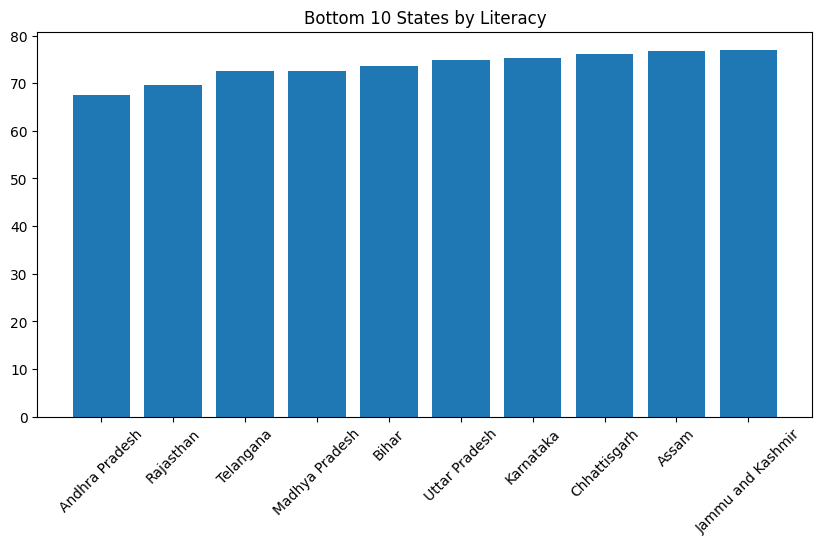

In [91]:
bottom = latest.sort_values(by="Literacy_Rate").head(10)
plt.figure(figsize=(10,5))
plt.bar(bottom["State"], bottom["Literacy_Rate"])
plt.xticks(rotation=45)
plt.title("Bottom 10 States by Literacy")
plt.show()

In [ ]:
#how literacy values are distributed

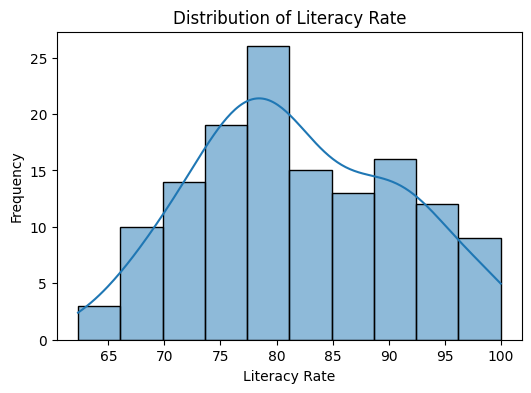

In [93]:
import seaborn as sns
plt.figure(figsize=(6,4))
sns.histplot(df_final["Literacy_Rate"], bins=10, kde=True)

plt.xlabel("Literacy Rate")
plt.ylabel("Frequency")
plt.title("Distribution of Literacy Rate")
plt.show()

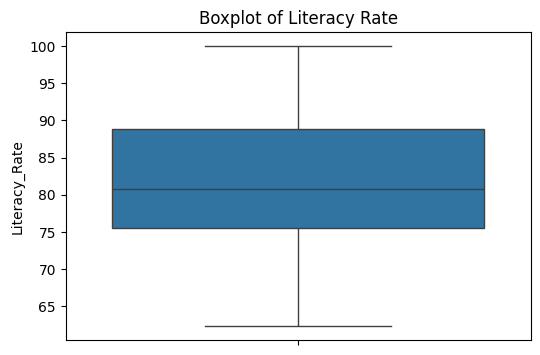

In [94]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df_final["Literacy_Rate"])
plt.title("Boxplot of Literacy Rate")

plt.show()

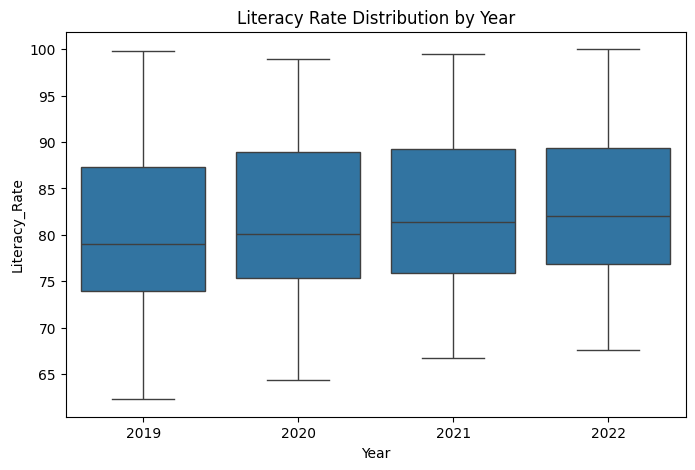

In [96]:
#Box_plot by year
plt.figure(figsize=(8,5))
sns.boxplot(x="Year", y="Literacy_Rate", data=df_final)
plt.title("Literacy Rate Distribution by Year")
plt.show()

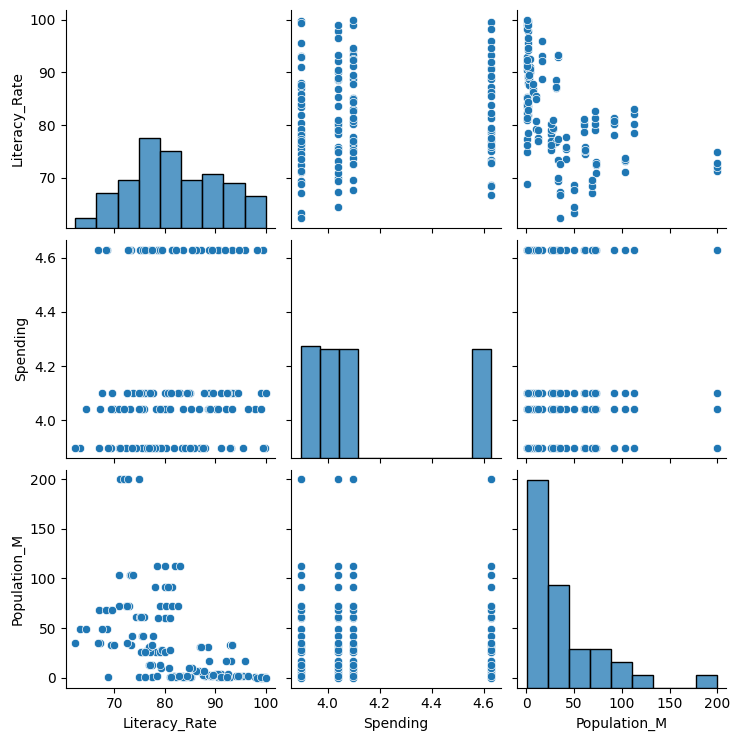

In [97]:
#pair plot
sns.pairplot(df_final[["Literacy_Rate", "Spending", "Population_M"]])

plt.show()

In [ ]:
#Feature Extraction

In [ ]:
#1.Per capita Spending


In [98]:
df_final["Per_Capita_Spending"] = df_final["Spending"] / df_final["Population"]

In [ ]:
#2.Population Scale

In [ ]:
df_final["Population_M"] = df_final["Population"] / 1_000_000

In [ ]:
#3.Year normalisation

In [99]:
df_final["Year_Scaled"] = df_final["Year"] - df_final["Year"].min()

In [ ]:
#spending population

In [100]:
df_final["Spending_Population"] = df_final["Spending"] * df_final["Population"]

In [101]:
df_final.corr(numeric_only=True)

,Year,Literacy_Rate,Population,Spending,Population_M,Per_Capita_Spending,Year_Scaled,Spending_Population
Year,1.000000,0.099397,0.007977,0.485938,0.007977,-0.000894,1.000000,0.034120
Literacy_Rate,0.099397,1.000000,-0.507344,0.048096,-0.507344,0.381298,0.099397,-0.502163
Population,0.007977,-0.507344,1.000000,0.005789,1.000000,-0.259281,0.007977,0.996309
Spending,0.485938,0.048096,0.005789,1.000000,0.005789,0.013028,0.485938,0.060311
Population_M,0.007977,-0.507344,1.000000,0.005789,1.000000,-0.259281,0.007977,0.996309
Per_Capita_Spending,-0.000894,0.381298,-0.259281,0.013028,-0.259281,1.000000,-0.000894,-0.258288
Year_Scaled,1.000000,0.099397,0.007977,0.485938,0.007977,-0.000894,1.000000,0.034120
Spending_Population,0.034120,-0.502163,0.996309,0.060311,0.996309,-0.258288,0.034120,1.000000


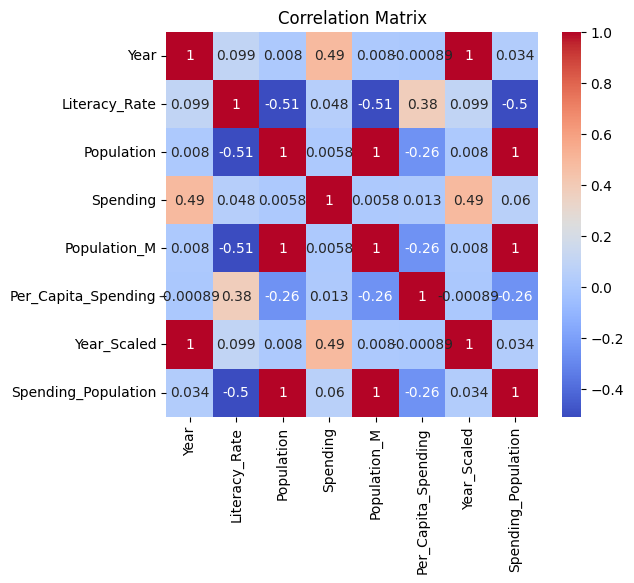

In [102]:
import seaborn as sns
corr = df_final.corr(numeric_only=True)
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Prediction

In [107]:
X = df_final[["Year", "Spending", "Population_M", "Per_Capita_Spending"]]
y = df_final["Literacy_Rate"]

In [108]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [109]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# Prediction

In [111]:
y_pred = model.predict(X_test)

In [113]:
from sklearn.metrics import mean_squared_error, r2_score

In [114]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 60.9016832759037
R2 Score: 0.3172781148238062


In [ ]:
#Actual Vs Predicted

In [115]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})


Sample Predictions:
     Actual  Predicted
107    76.8  82.828827
106    82.8  86.178835
12     92.9  79.910264
26     71.2  64.561879
125    69.6  79.359461


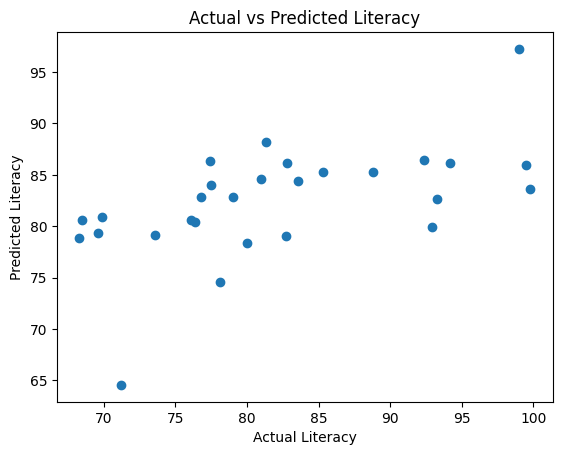

In [116]:
print("\nSample Predictions:")
print(results.head())
# 9. Visualization
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Literacy")
plt.ylabel("Predicted Literacy")
plt.title("Actual vs Predicted Literacy")
plt.show()

In [ ]:
#T-Test
# we will be dividing our data into : a) High spending , b)Low spending

In [117]:
median_spending = df_final["Spending"].median()
high_spending = df_final[df_final["Spending"] > median_spending]
low_spending = df_final[df_final["Spending"] <= median_spending]

In [118]:
high_lit = high_spending["Literacy_Rate"]
low_lit = low_spending["Literacy_Rate"]

In [ ]:
#Apply T-test

In [119]:
from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(high_lit, low_lit)
print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.9720363313911476
P-value: 0.33277088712102193


In [ ]:
#here spending has significant impact on literacy as p<0.5

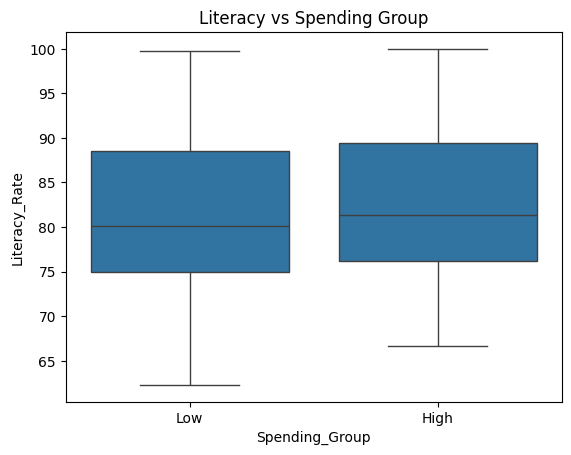

In [120]:
import seaborn as sns
df_final["Spending_Group"] = ["High" if x > median_spending else "Low" for x in df_final["Spending"]]
sns.boxplot(x="Spending_Group", y="Literacy_Rate", data=df_final)

plt.title("Literacy vs Spending Group")
plt.show()